In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt
style.use("ggplot")
import statsmodels.formula.api as smf
import matplotlib
from cycler import cycler

default_cycler = (cycler(color=['0.3', '0.5', '0.7', '0.5']))

color=['0.3', '0.5', '0.7', '0.9']
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

plt.rc('axes', prop_cycle=default_cycler)

# course DAG drawing + gain curves (matplotlib only, no system deps)
import course_helpers as chh
import fwl_proj_helpers as fp


In [2]:
# =============================================================================
#  APPLY THEME  --  Beamer "Madrid" look. Re-run any time to refresh styling.
# =============================================================================
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
apply_beamer_theme(
    "madrid",
    skip_font_download=True,
    author="Robert Pettis",
    date="Fall 2026",
    show_slide_number=True,
    cell_tags=True,
    notebook_path="04-The-Unreasonable-Effectiveness-of-Linear-Regression.ipynb",
)

<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 62 cell(s):
 cell_index    slide_id                                  tags
         10   slide-5-0 slide_hide_prompt, slide_remove_input
         12   slide-5-1 slide_hide_prompt, slide_remove_input
         14   slide-5-3 slide_hide_prompt, slide_remove_input
         18   slide-6-2 slide_hide_prompt, slide_remove_input
         20   slide-6-3 slide_hide_prompt, slide_remove_input
         24   slide-7-1 slide_hide_prompt, slide_remove_input
         26   slide-8-0 slide_hide_prompt, slide_remove_input
         35  slide-11-2 slide_hide_prompt, slide_remove_input
         37  slide-12-0 slide_hide_prompt, slide_remove_input
         39  slide-12-1 slide_hide_prompt, slide_remove_input
         41  slide-13-0 slide_hide_prompt, slide_remove_input
         44  slide-14-0 slide_hide_prompt, slide_remove_input
         47  slide-15-0 slide_hide_prompt, slide_remove_input
         49  slide-15-1 slide_hide_prompt, slide_remove_input
         51  slide-15-2 slide_

In [3]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed

<div class="beamer-meta" data-author="Robert Pettis" data-date="Fall 2026"></div>

# The Unreasonable Effectiveness of Linear Regression

### Causal Machine Learning

<br>

<b style="color:#73000A;">Robert Pettis</b>
Fall 2026

## Before We Start: Updating Your Repo

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Reminder</span> &nbsp;same git rhythm as the setup lecture.

| command | what it does |
|---|---|
| `git pull upstream main` | grab today's lecture before class |
| `git checkout -b ps1` | a branch for your own work |
| `git add .` then `git commit -m "..."` | snapshot your changes |
| `git push origin ps1` | send it to your fork, then open a pull request |
| `git status` | what changed, any time |

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:11px 16px; margin-top:13px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Lost?</span> <span style="color:#2a2a2a; font-size:1.06em;"><code>git status</code> is always safe and usually tells you what to do. The <b>Sync fork</b> button on GitHub does the pull for you.</span></div>

## Last Time: the Graph Says Which Variables to Control

- Conditioning on a <b style="color:#73000A;">confounder</b> closes a back door, and that is the fix for confounding
- Conditioning on a <b style="color:#73000A;">collider</b>, or on anything it caused, opens a path that was shut
- Conditioning on anything <b style="color:#73000A;">downstream of the treatment</b> throws away part of the effect
- So conditioning is neither good nor bad on its own. The graph decides

<b style="color:#73000A;">Today:</b> the graph told us <i>which</i> variables to condition on. It never told us <i>how</i>. 

## Back to the Bias Term, Now Remove It

Chapter 3 named the bias term: an open backdoor path through a confounder.

$$E[Y \mid T{=}1] - E[Y \mid T{=}0] = \underbrace{E[Y_1 - Y_0 \mid T{=}1]}_{\text{effect (ATT)}} + \underbrace{E[Y_0 \mid T{=}1] - E[Y_0 \mid T{=}0]}_{\text{BIAS}}$$

- Regression lets us <b style="color:#73000A;">measure</b> that term and <b style="color:#73000A;">remove</b> it
- Leave a confounder out and the bias term is <b style="color:#73000A;">omitted-variable bias</b>
- Put it in, and orthogonalization closes the path by construction

## All You Need Is Linear Regression

- Regression: 200+ years old, yet catches even the best causal inference researchers
- In this chapter: linear regression as debiasing technique
- Baseline and foundation for more complex modeling

### The Papers That Say Otherwise

Regression is a hundred years old and still catching working researchers out. Three recent examples, all worth your time:

- <b style="color:#73000A;">Goodman-Bacon (2021)</b>: with staggered treatment timing, two-way fixed effects quietly uses already-treated units as controls
- <b style="color:#73000A;">Słoczyński (2022)</b>: with heterogeneous effects, the OLS estimand puts most of its weight on the smaller group
- <b style="color:#73000A;">Goldsmith-Pinkham, Hull and Kolesár (2024)</b>: with several treatments at once, each coefficient is contaminated by the others

Every one of these is a statement about <b style="color:#73000A;">what regression is averaging</b>, and we will meet that question again today.

## The Bank Dataset

One row per customer, 50,000 of them:

- What the bank knew <b style="color:#73000A;">before</b> deciding: wage, education, experience, marital status, and two credit scores from two different models
- The <b style="color:#73000A;">credit limit</b> it then granted, which is our treatment
- Whether that customer <b style="color:#73000A;">defaulted</b>, which is our outcome

In [198]:
risk_data = pd.read_csv("./data/risk_data.csv")

risk_data.head()

,wage,educ,exper,married,credit_score1,credit_score2,credit_limit,default
0,950.0,11,16,1,500.0,518.0,3200.0,0
1,780.0,11,7,1,414.0,429.0,1700.0,0
2,1230.0,14,9,1,586.0,571.0,4200.0,0
3,1040.0,15,8,1,379.0,411.0,1500.0,0
4,1000.0,16,1,1,379.0,518.0,1800.0,0


### Why the Comparison Is Not Fair

Risk is what the bank actually cares about and cannot see. It uses $X$ (wage, scores, tenure) as a stand-in, and $X$ decides the limit.

- $X$ drives the limit, because the underwriting model is built on it
- $X$ also drives default, because risky customers default
- That is an open back door, and it is the reason a raw comparison of high-limit and low-limit customers is not an experiment
- The limit takes hundreds of values, so there are no treated and control groups here. The effect is a <b style="color:#73000A;">slope</b>:

$$ATE = \frac{\partial}{\partial t}\,E[y \mid t] \qquad \text{change in default per extra dollar of limit}$$

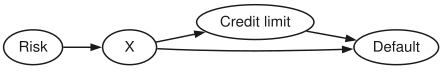

In [4]:
chh.draw_dag([("Risk", "X"), ("X", "Credit limit"), ("X", "Default"),
              ("Credit limit", "Default")])

### Start With the Obvious Regression

$$\texttt{default}_i = \beta_0 + \beta_1 \texttt{limit}_i + e_i$$

- Fit it and $\hat{\beta}_1$ comes out <b style="color:#73000A;">negative</b>: about $-2.4 \times 10^{-5}$ per dollar
- Read literally, handing a customer another 1,000 dollars of credit makes them <b style="color:#73000A;">less</b> likely to default
- Nobody believes that. The bank gave the biggest lines to the safest customers, and the regression is reading the bank's own policy back to us
- So the raw slope is treatment assignment, not treatment effect. The rest of the lecture is about the difference

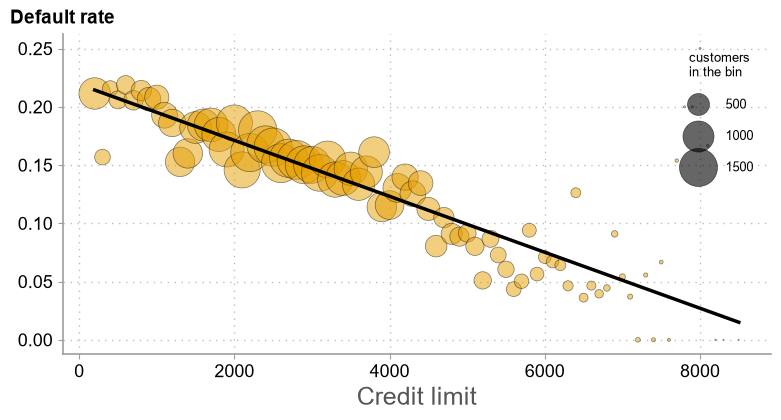

In [5]:
use_plotplainblind("mono")
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf

risk_data = pd.read_csv("./data/risk_data.csv")
model = smf.ols('default ~ credit_limit', data=risk_data).fit()

fig, ax = plt.subplots(figsize=(8, 4.4))
plt_df = (risk_data
          .assign(size=1)
          .groupby("credit_limit")
          .agg({"default": "mean", "size": "sum"})
          .reset_index()
          .assign(prediction=lambda d: model.predict(d)))

sc = ax.scatter(plt_df["credit_limit"], plt_df["default"],
           s=plt_df["size"]/2, alpha=0.5, color="#E69F00", edgecolors="black", linewidth=0.5)
ax.plot(plt_df["credit_limit"], plt_df["prediction"],
        color="black", linewidth=2.5, marker="")
ax.set_xlabel("Credit limit")
set_top_ylabel(ax, "Default rate", fontsize=14, fontweight="bold")
sizes_handles, sizes_labels = sc.legend_elements(
    prop="sizes", num=4, alpha=0.6, func=lambda s: s * 2)
ax.legend(sizes_handles, sizes_labels, title="customers\nin the bin",
          loc="upper right", framealpha=0.9, labelspacing=1.5,
          borderpad=0.9, handletextpad=1.2, fontsize=9, title_fontsize=9)
plt.tight_layout()

## An Answer to Confounding?

$$ATE = E_X\big\{\,E[Y \mid T{=}1, X{=}x] - E[Y \mid T{=}0, X{=}x]\,\big\}$$

In words:

- Gather customers who <b style="color:#73000A;">look the same on $X$</b>. Any difference in default between them cannot be blamed on $X$, because they share it
- Inside that group, compare the ones who got the treatment with the ones who did not
- Repeat for every group, then average those comparisons, weighting each group by how many customers are in it

No line, no model, no assumption about the shape of anything. Just comparisons among lookalikes.

### A Toy Bank: 24 Customers

Every customer is one of two kinds, <b style="color:#73000A;">safe</b> or <b style="color:#73000A;">risky</b>. That is the control. Each was given a <b style="color:#73000A;">big</b> or a <b style="color:#73000A;">small</b> credit line, the treatment. Each either defaulted or did not, the outcome.

| kind of customer | credit line | how many | defaulted | default rate |
|---|---|---|---|---|
| safe | big | 10 | 1 | 1/10 = 0.10 |
| safe | small | 2 | 0 | 0/2 = 0.00 |
| risky | big | 2 | 1 | 1/2 = 0.50 |
| risky | small | 10 | 4 | 4/10 = 0.40 |

- Safe customers mostly got big lines, risky customers mostly got small ones

### Now Compare Them Two Ways

<b style="color:#73000A;">Ignore the kind of customer.</b> Pool everyone and compare big lines with small:

$$\underbrace{\frac{1 + 1}{10 + 2}}_{\text{big lines}} - \underbrace{\frac{0 + 4}{2 + 10}}_{\text{small lines}} = \frac{2}{12} - \frac{4}{12} = -0.167$$

Big lines look <b style="color:#73000A;">17 points safer</b>.

<b style="color:#73000A;">Compare inside each kind, then average.</b> Twelve customers are safe and twelve are risky:

$$\underbrace{\frac{12}{24}\big(0.10 - 0.00\big)}_{\text{safe customers}} + \underbrace{\frac{12}{24}\big(0.50 - 0.40\big)}_{\text{risky customers}} = +0.10$$

Big lines are <b style="color:#73000A;">10 points riskier</b>. Same 24 people, opposite conclusion, and the only change was comparing like with like.

- Which answer is believable? A bigger line means more available debt, more spending, and more balance to service, so <b style="color:#73000A;">more credit really should mean more default</b>
- The negative number was never the effect of credit. It was the bank's underwriting policy, read back to us: the customers it judged safe are the ones it handed the big lines to

In [6]:
# the same 24 customers, if you want to poke at them
toy = pd.DataFrame({
    "kind":  ["safe"] * 12 + ["risky"] * 12,
    "line":  ["big"] * 10 + ["small"] * 2 + ["big"] * 2 + ["small"] * 10,
    "default": [1] + [0] * 9        # safe, big line:   1 default in 10
             + [0] * 2              # safe, small line: 0 defaults in 2
             + [1, 0]               # risky, big line:  1 default in 2
             + [1, 1, 1, 1] + [0] * 6,   # risky, small line: 4 defaults in 10
})

rate = toy.groupby(["kind", "line"], observed=True)["default"].mean()
share = toy.groupby("kind", observed=True).size() / len(toy)

pooled = (toy.loc[toy.line == "big", "default"].mean()
          - toy.loc[toy.line == "small", "default"].mean())
adjusted = sum(share[k] * (rate[(k, "big")] - rate[(k, "small")])
               for k in ["safe", "risky"])

print(f"pooling everyone            : {pooled:+.3f}")
print(f"comparing inside each kind  : {adjusted:+.3f}")

pooling everyone            : -0.167
comparing inside each kind  : +0.100


### Add a second control.... Annnnnnnnd It Stops Working

The toy had <b style="color:#73000A;">one</b> control with <b style="color:#73000A;">two</b> values, so there were two groups and both were full. The bank has neither luxury. Ask for real customers who match on <b style="color:#73000A;">both</b> credit scores and count how many share each pair:

- Every count below is $1$. One customer per group
- A group of one has nobody to compare against, so it contributes no difference at all
- And two scores is nowhere near the real problem. The bank underwrites on roughly <b style="color:#73000A;">10</b> variables, and at only 3 levels each that is $3^{10} = 59{,}049$ groups to fill from 50,000 customers
- Impossible to run

In [7]:
risk_data = pd.read_csv("./data/risk_data.csv")

# just two of the bank's columns: how many customers share a pair of scores?
risk_data.groupby(["credit_score1", "credit_score2"]).size().head()

credit_score1  credit_score2
34.0           339.0            1
               500.0            1
52.0           518.0            1
69.0           214.0            1
               357.0            1
dtype: int64

### Two Vocabularies, One Idea

Half this room learned it in econometrics, half in machine learning. Same objects, different words.

| Machine learning | Econometrics and causal inference |
|---|---|
| feature | covariate, regressor, control |
| weight | parameter, coefficient |
| target, label | outcome, dependent variable |
| fitting, training | estimation |
| squared loss | sum of squared residuals |

- Neither dialect is more correct. Read both, since the literature you need is written in both
- Where the two really part ways is <b style="color:#73000A;">purpose</b>: prediction wants $\hat{y}$, we want one coefficient

## Adjusting with Regression

Put the confounders in the model.

$$\texttt{default}_i = \beta_0 + \beta_1 \texttt{limit}_i + \boldsymbol{\theta}'\mathbf{X}_i + e_i$$

- $\boldsymbol{\theta}$ holds the coefficients on the controls. They are <b style="color:#73000A;">nuisance parameters</b>: needed, never interpreted
- $\beta_1$ is now the effect of another dollar of limit <b style="color:#73000A;">holding the controls fixed</b>
- Which is a partial derivative, $\partial E[y \mid t, X] / \partial t$, and the reason the interpretation shifts
- Add wage and the two credit scores and the sign flips from negative to positive

### Reading the Adjusted Estimate

$$\texttt{default} \sim \texttt{credit limit} + \texttt{wage} + \texttt{credit score 1} + \texttt{credit score 2}$$

- The coefficient on the limit is now <b style="color:#73000A;">positive</b>: $+3.06 \times 10^{-6}$, and significant
- Do not be put off by how small it looks. Limits run in the thousands and default is 0 or 1, so a single dollar should move it very little. A thousand dollars raises the default rate by about <b style="color:#73000A;">0.3 percentage points</b>

In [8]:
formula = 'default ~ credit_limit + wage+credit_score1+credit_score2'
model = smf.ols(formula, data=risk_data).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.4037,0.009,46.939,0.000,0.387,0.421
credit_limit,3.063e-06,1.54e-06,1.987,0.047,4.16e-08,6.08e-06
wage,-8.822e-05,6.07e-06,-14.541,0.000,-0.000,-7.63e-05
credit_score1,-4.175e-05,1.83e-05,-2.278,0.023,-7.77e-05,-5.82e-06
credit_score2,-0.0003,1.52e-05,-20.055,0.000,-0.000,-0.000


## What Regression Solves

Regression solves the <b style="color:#73000A;">best linear prediction</b> problem:

$$\beta^{*} = \arg\min_{\beta}\; E\big[(Y_i - X_i'\beta)^2\big]$$

- Differentiate, set to zero, and the solution is $\beta^{*} = E[X'X]^{-1}E[X'Y]$
- Replace the expectations with sample averages and you have the estimator $\hat{\beta} = (X'X)^{-1}X'y$
- Notice what was <b style="color:#73000A;">not</b> assumed: no true linear model, no normal errors, no causality. It is a projection
- Machine learning calls the same objective empirical risk minimization under squared loss

In [9]:
X_cols = ["credit_limit", "wage", "credit_score1", "credit_score2"]
X = risk_data[X_cols].assign(intercep=1)
y = risk_data["default"]

def regress(y, X):                      # beta = (X'X)^-1 X'y, by hand
    return np.linalg.inv(X.T.dot(X)).dot(X.T.dot(y))

by_hand = regress(y, X)
by_smf = smf.ols("default ~ credit_limit + wage + credit_score1 + credit_score2",
                 data=risk_data).fit().params

print("by hand      ", np.round(by_hand[:4], 9))
print("statsmodels  ", np.round(by_smf[X_cols].values, 9))

by hand       [ 3.06300e-06 -8.82160e-05 -4.17470e-05 -3.03928e-04]
statsmodels   [ 3.06300e-06 -8.82160e-05 -4.17470e-05 -3.03928e-04]


### One Regressor: Covariance over Variance

With a single regressor $T$ and nothing else in the model:

$$\hat{\tau} = \frac{\operatorname{Cov}(Y_i, T_i)}{\operatorname{Var}(T_i)} = \frac{E\big[(T_i - \bar{T})(Y_i - \bar{Y})\big]}{E\big[(T_i - \bar{T})^2\big]}$$

- The top asks how $T$ and $Y$ move together
- The bottom rescales that into units of $T$, so the answer is per dollar of credit limit
- If $T$ was randomly assigned, this is the ATE and we are finished
- It is the same $(X'X)^{-1}X'y$ as before: $X'y$ is the covariance, $X'X$ the variance

### Many Regressors: What the Coefficient Really Is

Now put the controls back, and keep caring about $\tau$ alone:

$$y_i = \beta_0 + \tau T_i + \beta_1 X_{1i} + \cdots + \beta_k X_{ki} + u_i
\qquad\Longrightarrow\qquad
\hat{\tau} = \frac{\operatorname{Cov}(Y_i, \tilde{T}_i)}{\operatorname{Var}(\tilde{T}_i)}$$

where $\tilde{T}_i$ is what is left of $T_i$ after the other covariates have predicted it.

- A multivariate coefficient <b style="color:#73000A;">is</b> a single variable coefficient, run on a cleaned treatment
- If you can predict $T$ from $X$, then $T$ is <b style="color:#73000A;">not</b> random
- Subtract that prediction and what remains cannot be predicted by $X$ at all
- Which is to say: $\tilde{T}$ is as good as randomly assigned, given $X$

## The Frisch-Waugh-Lovell Theorem

One big regression, $\hat{\boldsymbol{\beta}} = (X'X)^{-1}X'y$, gives every coefficient at once. FWL gets the coefficient on a single variable $T$, holding the controls $X$ fixed, with <b style="color:#73000A;">three small regressions</b>:

<b style="color:#73000A;">Step 1. Clean $T$ of $X$.</b> Regress $T$ on $X$, keep the residual:
$$T = \delta_0 + \delta_1 X + \varepsilon_T \quad\Longrightarrow\quad \tilde{T} = T - (\hat{\delta}_0 + \hat{\delta}_1 X) = \hat{\varepsilon}_T$$

<b style="color:#73000A;">Step 2. Clean $Y$ of $X$.</b> The same move on the outcome:
$$Y = \gamma_0 + \gamma_1 X + \varepsilon_Y \quad\Longrightarrow\quad \tilde{Y} = Y - (\hat{\gamma}_0 + \hat{\gamma}_1 X) = \hat{\varepsilon}_Y$$

<b style="color:#73000A;">Step 3. Regress leftover on leftover.</b>
$$\tilde{Y} = \tau\,\tilde{T} + \varepsilon \quad\Longrightarrow\quad \hat{\tau} = \frac{\operatorname{Cov}(\tilde{Y}, \tilde{T})}{\operatorname{Var}(\tilde{T})}$$

- Left of each arrow is the <b style="color:#73000A;">model</b>, with its error. Right of it is what we can <b style="color:#73000A;">compute</b>: the fitted residual, $\tilde{T} = \hat{\varepsilon}_T$
- $\hat{\tau}$ is <b style="color:#73000A;">exactly</b> the coefficient on $T$ from the full regression: same number, three easy steps
- With no controls, Step 3 is just $\operatorname{Cov}(Y, T)/\operatorname{Var}(T)$; if $T$ is randomized, that is the ATE

### The Same Three Steps, in Matrix Form

For the compact version, let $M_X = I - X(X'X)^{-1}X'$ be the <b style="color:#73000A;">residual maker</b>: multiplying by it regresses on $X$ and hands back the residual, in one stroke.

- Steps 1 and 2 at once: $\;\tilde{T} = M_X T\;$ and $\;\tilde{Y} = M_X Y$
- Step 3 is a regression through the origin: $\;\hat{\tau} = \dfrac{\tilde{T}'\tilde{Y}}{\tilde{T}'\tilde{T}}$
- Same estimate as the coefficient on $T$ in the full model $Y = X\beta + \tau T + u$, now on one line. $X$ can be one control or many

## What Is Regression Actually Doing?

We have the theorem: three regressions, and the same number falls out. The algebra never shows <b style="color:#73000A;">why</b>.

- There is a picture behind the formulas, and it is simple enough to draw by hand
- Regression is a <b style="color:#73000A;">projection</b>: a shadow cast onto a flat surface
- Residualizing is what is left over after the shadow is taken away
- Seen that way, FWL is a statement about geometry rather than an accident of algebra

## Regression Is Projection

*A geometric route to Frisch, Waugh, and Lovell.*

### Three Observations, Not Three Variables

$$\begin{bmatrix} \hat{y}_1 \\ \hat{y}_2 \\ \hat{y}_3 \end{bmatrix}
= \beta_0 \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}
+ \beta_1 \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix}$$

- Each column holds one number per observation, so with $n = 3$ the vectors sit in ordinary 3D
- The three axes are the three <b style="color:#73000A;">observations</b>, not three variables
- We will follow one concrete case: $\mathbf{1} = (1,1,1)$, $\mathbf{x} = (-1,1,3)$, $\mathbf{y} = (2,0,4)$
- So $\hat{\mathbf{y}}$ is trapped in the <b style="color:#73000A;">plane</b> those two span, and the picture below is literal, not a metaphor

### The Numbers We Will Follow

- Three observations, one regressor $\mathbf{x}$ plus the constant $\mathbf{1}$
- Fit it with `smf.ols`, where the intercept <b style="color:#73000A;">is</b> the $\mathbf{1}$ vector
- The data are integers and the fit lands in halves, easy to check by hand

In [205]:
import pandas as pd
import statsmodels.formula.api as smf

df = pd.DataFrame({"y": [2, 0, 4], "x": [-1, 1, 3]})

model = smf.ols("y ~ x", data=df).fit()      # the fitted constant is the 1 vector
beta0 = model.params["Intercept"]
beta1 = model.params["x"]

print(model.params.round(2))
print("y-hat    =", model.fittedvalues.round().to_numpy().astype(int))
print("residual =", model.resid.round().to_numpy().astype(int))

Intercept    1.5
x            0.5
dtype: float64
y-hat    = [1 2 3]
residual = [ 1 -2  1]


## The Regressors Span a Plane

- $\mathbf{1}$ and $\mathbf{x}$ are two arrows in observation space
- Every combination $\beta_0 \mathbf{1} + \beta_1 \mathbf{x}$ lands somewhere on the flat sheet they sweep out
- That sheet is the <b style="color:#73000A;">column space</b>: every fit the model can possibly produce

In [206]:
fp.anim_plane()

### The Outcome Lives Off the Plane

- The actual data $\mathbf{y}$ almost never sits in the plane
- No choice of $\beta_0, \beta_1$ reproduces it exactly
- The best the model can do is find the <b style="color:#73000A;">closest point on the plane</b>

In [207]:
fp.anim_off()

## What a Projection Is: the Shadow on the Wall

- Shine a flashlight at $\mathbf{y}$, angled so the beam hits the plane
- The <b style="color:#73000A;">shadow</b> $\mathbf{y}$ casts on the plane is its closest point: the fit $\hat{\mathbf{y}}$
- Tilt the light and the shadow slides <b style="color:#73000A;">farther</b> from $\mathbf{y}$; watch the gap grow
- Only with the light <b style="color:#73000A;">straight down</b> is the shadow as close as it can be

In [208]:
fp.flashlight_animation()

### Why Straight Down: the Origin of "Ordinary"

- If the gap leaned even slightly <b style="color:#73000A;">along</b> the plane, you could slide $\hat{\mathbf{y}}$ that way and get closer
- Only when the gap points <b style="color:#73000A;">straight off</b> the plane is there nothing left to gain
- "Straight off" means <b style="color:#73000A;">perpendicular</b>, which is exactly what <b style="color:#73000A;">orthogonal</b> means
- Choosing that perpendicular drop is the <b style="color:#73000A;">ordinary</b> in ordinary least squares

## OLS Drops a Perpendicular

- The closest point is the <b style="color:#73000A;">shadow</b> of $\mathbf{y}$ on the plane: the fitted values $\hat{\mathbf{y}}$
- What is left over, $\mathbf{y} - \hat{\mathbf{y}}$, is the <b style="color:#73000A;">residual</b>
- Closest means the residual meets the plane at a <b style="color:#73000A;">right angle</b>
- That perpendicularity is exactly the normal equations, $\mathbf{x}'(\mathbf{y} - \hat{\mathbf{y}}) = 0$

In [209]:
fp.anim_proj()

### Where $\mathbf{M} = \mathbf{I} - \mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top$

## $\hat{y}$ is a Linear Combination

$$\hat{\mathbf{y}} = \beta_0 \mathbf{1} + \beta_1 \mathbf{x} = 1.5,(1,1,1) + 0.5,(-1,1,3) = (1,2,3)$$

* $\beta_0\mathbf{1}$ and $\beta_1\mathbf{x}$ are <b style="color:#73000A;">scaled copies</b> of $\mathbf{1}$ and $\mathbf{x}$: different arrows along the same lines, not $\mathbf{1}$ and $\mathbf{x}$ themselves.
* Here, $\beta_0\mathbf{1}$ is $1.5$ times $\mathbf{1}$, while $\beta_1\mathbf{x}$ is half of $\mathbf{x}$.
* $\hat{\mathbf{y}}$ is the <b style="color:#73000A;">result</b> of adding those two scaled arrows: the diagonal of the parallelogram they form.
* $\beta_0$ and $\beta_1$ tell us <b style="color:#73000A;">how much of each direction</b> the fit uses.

In [210]:
fp.anim_paral()

### Another Way to Write It: the Running Sum

$$\mathbf{y} = \underbrace{\beta_0 \mathbf{1} + \beta_1 \mathbf{x}}_{\hat{\mathbf{y}},\ \text{ the fit}} + \underbrace{M\mathbf{y}}_{\text{residual}}$$

- The residual is <b style="color:#73000A;">data minus fit</b>, so data equals fit plus residual, always
- Same pieces, now laid <b style="color:#73000A;">head to tail</b>: $\beta_0\mathbf{1}$, then $\beta_1\mathbf{x}$ from its tip, landing on $\hat{\mathbf{y}}$
- Then up the residual $M\mathbf{y}$ to reach the data $\mathbf{y}$, so $\beta_1\mathbf{x}$ starts at a tip, not the origin

In [211]:
fp.anim_decomp()

### Order Does Not Matter

- The three legs $\beta_0\mathbf{1}$, $\beta_1\mathbf{x}$, and $M\mathbf{y}$ can be laid in any of <b style="color:#73000A;">six</b> orders
- Every order traces a different path, but all six land on the same $\mathbf{y}$
- Vector addition is <b style="color:#73000A;">commutative</b>: $\;\mathbf{a}+\mathbf{b}+\mathbf{c}$ does not depend on the order

In [212]:
fp.commute_animation()

## What the Slope on x Really Measures

The fit leans on the constant and on $\mathbf{x}$ together:
$$\hat{\mathbf{y}} = 1.5\,\mathbf{1} + 0.5\,\mathbf{x}$$

So what does the $0.5$ on $\mathbf{x}$ measure by itself:

- Take out of $\mathbf{x}$ the part the constant explains, and call what is left $\tilde{\mathbf{x}}$
- Take out of $\mathbf{y}$ the part the constant explains, and call what is left $\tilde{\mathbf{y}}$
- Fit a line through the leftovers: how $\tilde{\mathbf{y}}$ moves with $\tilde{\mathbf{x}}$ is the $0.5$
- With only a constant in the model, the part it explains is just the <b style="color:#73000A;">average</b>, so each step is subtract the average

### Controlling for a Variable: Take Out What It Explains

To control for a variable, work out how much of your data that variable can account for, remove it, and keep the rest.

1. Use the control to predict the variable you care about, as well as it can be predicted
2. Subtract that prediction
3. What is left is the part the control could not account for. That is what you work with

How good a prediction the control can make depends on what kind of variable it is:

- A <b style="color:#73000A;">constant</b> is the same number for everyone, so the best it can do is predict the overall average for every row
- A <b style="color:#73000A;">category</b>, like which school a student attends, can predict a different number for each category: that category's average
- A <b style="color:#73000A;">measured number</b>, like age, can predict along a fitted line: a different value at every age

Our only control is the constant, so the prediction for $\mathbf{x}$ is $\bar{x}$ in every row, and what is left is $\mathbf{x} - \bar{x}\,\mathbf{1}$.

### What It Looks Like With a Category

Three students, one test score each: $10$, $6$ and $3$. The first two go to school A, the third goes to school B. Control for school.

- School A's two students average $8$, so what is left of them is $+2$ and $-2$
- School B's one student averages $3$, so what is left of that student is $0$
- Controlled scores: $(+2, -2, 0)$. Every student is now measured against <b style="color:#73000A;">their own school</b>, not against the country

Two things to notice:

- Differences <b style="color:#73000A;">between</b> schools are gone. Only differences <b style="color:#73000A;">within</b> a school survive
- The student alone at school B contributes nothing at all. With no classmate to compare against, the school average <b>is</b> that student's score

A constant is the same move with one enormous category: everybody in a single group. Its average is the overall average, so controlling for a constant is just subtracting the mean. That is Step 1 and Step 2, next.

### Step 1: Take the Average Out of x

The average of $\mathbf{x} = (-1, 1, 3)$ is $1$. Remove it from every entry:
$$\tilde{\mathbf{x}} = \mathbf{x} - \bar{x}\,\mathbf{1} = (-1,1,3) - (1,1,1) = (-2,\,0,\,2)$$

- What the constant could explain was the level, the average $1$; $\tilde{\mathbf{x}}$ is what is left, the ups and downs around it
- In the picture, $\tilde{\mathbf{x}}$ is the part of $\mathbf{x}$ lying flat in the floor, at a right angle to the ones direction

In [213]:
fp.anim_partial()

### Step 2: Take the Average Out of y

The average of $\mathbf{y} = (2, 0, 4)$ is $2$. Remove it the same way:
$$\tilde{\mathbf{y}} = \mathbf{y} - \bar{y}\,\mathbf{1} = (2,0,4) - (2,2,2) = (0,\,-2,\,2)$$

- Exactly the move from step 1, now on $\mathbf{y}$ instead of $\mathbf{x}$
- $\tilde{\mathbf{y}}$ is what is left of $\mathbf{y}$ once its average level is gone

In [214]:
fp.anim_partial_y()

### Both Leftovers, Square to the Constant

$\tilde{\mathbf{x}}$ and $\tilde{\mathbf{y}}$ from the two steps, drawn together:

- Demeaning takes away the part along $\mathbf{1}$, so what is left of each vector sits at a <b style="color:#73000A;">right angle to $\mathbf{1}$</b> (the two boxes)
- Both leftovers now sit in the same flat world square to the constant, which is where the next slide reads off their slope
- They are square to $\mathbf{1}$, but <b style="color:#73000A;">not</b> to each other: the angle between $\tilde{\mathbf{x}}$ and $\tilde{\mathbf{y}}$ is what the slope measures

In [215]:
fp.anim_together()

### A Right Angle Means Uncorrelated

The angle between two variables' arrows tells you their correlation, no formula needed. Read it straight off the dial:

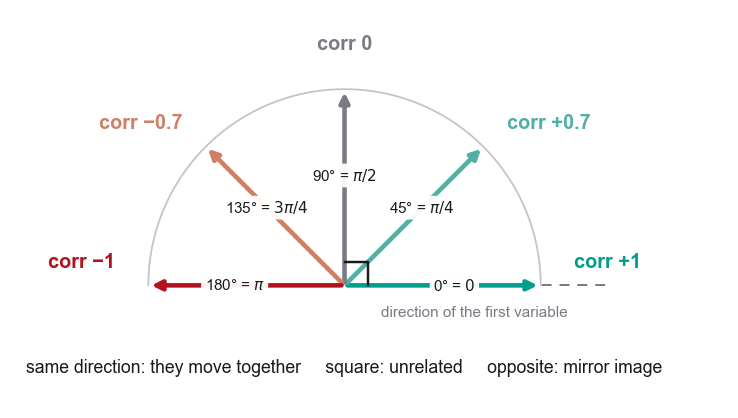

In [216]:
fp.fig_corr_dial()

### Step 3: Fit a Line Through the Leftovers

Line $\tilde{\mathbf{y}}$ up against $\tilde{\mathbf{x}}$ and read the slope:

$$\text{slope} = \frac{\tilde{\mathbf{x}}'\tilde{\mathbf{y}}}{\tilde{\mathbf{x}}'\tilde{\mathbf{x}}}
\qquad\text{where}\qquad \tilde{\mathbf{x}} = (-2,\,0,\,2),\quad \tilde{\mathbf{y}} = (0,\,-2,\,2)$$

The mark $'$ just tips a column on its side. A row times a column means: multiply the matching entries, then add them up.

$$\tilde{\mathbf{x}}'\tilde{\mathbf{y}} =
\begin{bmatrix} -2 & 0 & 2 \end{bmatrix}
\begin{bmatrix} 0 \\ -2 \\ 2 \end{bmatrix}
= (-2)(0) + (0)(-2) + (2)(2) = 4$$

$$\tilde{\mathbf{x}}'\tilde{\mathbf{x}} =
\begin{bmatrix} -2 & 0 & 2 \end{bmatrix}
\begin{bmatrix} -2 \\ 0 \\ 2 \end{bmatrix}
= (-2)(-2) + (0)(0) + (2)(2) = 8$$

$$\text{slope} = \frac{4}{8} = 0.5$$

### The Same $0.5$ the Full Fit Gave

- We never ran the two-variable regression to get it. We removed the average from $\mathbf{x}$, removed the average from $\mathbf{y}$, and fitted one line through what was left
- It is the <b style="color:#73000A;">same</b> $0.5$ that sits in front of $\mathbf{x}$ in the full fit $\hat{\mathbf{y}} = 1.5\,\mathbf{1} + 0.5\,\mathbf{x}$
- That is Frisch, Waugh and Lovell, on three numbers you can check by hand
- The constant was the control here. Swap it for wage and two credit scores and nothing about the recipe changes

And the picture below is the projection again, one dimension down:

$$\beta_1\tilde{\mathbf{x}} = \frac{\tilde{\mathbf{x}}'\tilde{\mathbf{y}}}{\tilde{\mathbf{x}}'\tilde{\mathbf{x}}}\,\tilde{\mathbf{x}} = \operatorname{proj}_{\tilde{\mathbf{x}}}\tilde{\mathbf{y}}$$

- $\hat{\mathbf{y}}$ was the shadow of $\mathbf{y}$ on a <b style="color:#73000A;">plane</b>. Here $\beta_1\tilde{\mathbf{x}}$ is the shadow of $\tilde{\mathbf{y}}$ on a single <b style="color:#73000A;">line</b>, so the dashed gap meets it at a right angle for the same reason
- That gap is $(0,-2,2) - (-1,0,1) = (1,-2,1)$: the same residual the full two-variable fit printed earlier
- FWL, said geometrically: dropping onto $\mathbf{1}$ and then onto what is left of $\mathbf{x}$ lands in the same place as dropping onto the plane they span

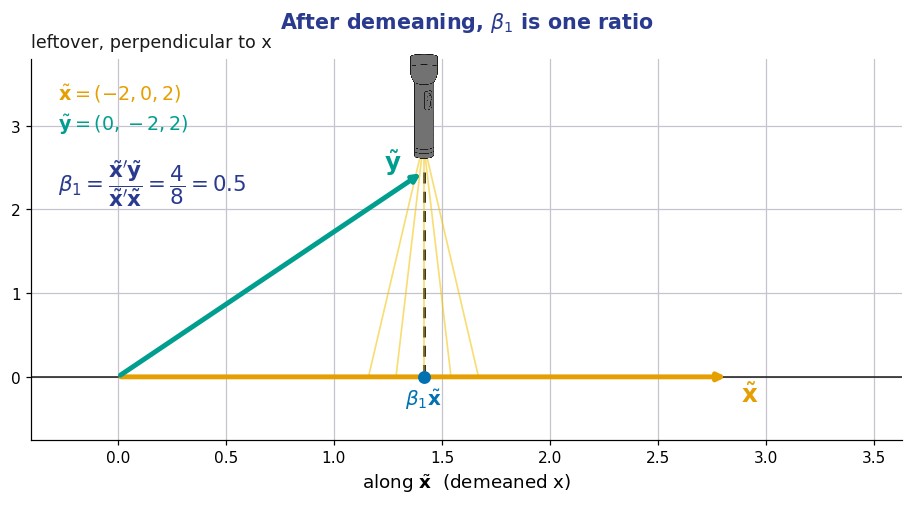

In [217]:
fp.fig_ratio()

### Check It in Code

The same tools as the regression lectures. Two fits, one number:

In [218]:
import pandas as pd
import statsmodels.formula.api as smf

df = pd.DataFrame({"x": [-1, 1, 3], "y": [2, 0, 4]})

full = smf.ols("y ~ x", data=df).fit()

df["x_left"] = df["x"] - df["x"].mean()
df["y_left"] = df["y"] - df["y"].mean()
leftovers = smf.ols("y_left ~ x_left - 1", data=df).fit()

print("slope on x, full two-variable fit:", round(full.params["x"], 3))
print("slope through the leftovers:      ", round(leftovers.params["x_left"], 3))

slope on x, full two-variable fit: 0.5
slope through the leftovers:       0.5


### Aside: the Same Thing in Matrix Form

For readers who want the linear algebra, subtracting the average is one matrix, the residual maker $M_1$:
$$M_1 = I - \tfrac{1}{n}\mathbf{1}\mathbf{1}', \qquad M_1\mathbf{z} = \mathbf{z} - \bar{z}\,\mathbf{1}$$

- Multiplying by $M_1$ subtracts the mean, so $M_1\mathbf{x} = \tilde{\mathbf{x}}$ and $M_1\mathbf{y} = \tilde{\mathbf{y}}$
- The slope through the leftovers is then $\beta_1 = \dfrac{\tilde{\mathbf{x}}'\tilde{\mathbf{y}}}{\tilde{\mathbf{x}}'\tilde{\mathbf{x}}} = \dfrac{4}{8} = 0.5$
- The same statement as the three steps above, written for those who prefer symbols

## Orthogonalization: Debias and Denoise

- We stated FWL's three steps up front; now watch them work on real confounded data
- <b style="color:#73000A;">Orthogonalize</b> is the name for Step 1: $\tilde{T}$ is uncorrelated with $X$, so the confounding is gone
- Debiasing (cleaning $T$) removes the bias; denoising (cleaning $Y$) tightens the estimate

### Watch It Happen: Debias, Then Denoise

- Three groups of $X$ confound $T$ and $Y$: raw slope is <b style="color:#73000A;">negative</b>
- Subtract $E[T|X]$: the groups slide together, bias is gone
- Subtract $E[Y|X]$: the cloud tightens, precision improves
- What is left is the <b style="color:#73000A;">true effect</b>

### Watch It Happen: Debias, Then Denoise

In [219]:
from IPython.display import HTML
HTML(chh.fwl_animation().to_html5_video())

### Why It Works: Debiasing

- The debiased T is uncorrelated with X by construction
- So when you regress $\tilde{Y}$ on $\tilde{T}$, you are not confounded by X
- Treatment looks as good as randomly assigned
- This is orthogonalization: removing the causal pathway through X
- In the plot, the average limit is added back to the residual so the axis still reads in dollars. Cosmetic only: shifting a variable cannot change a slope

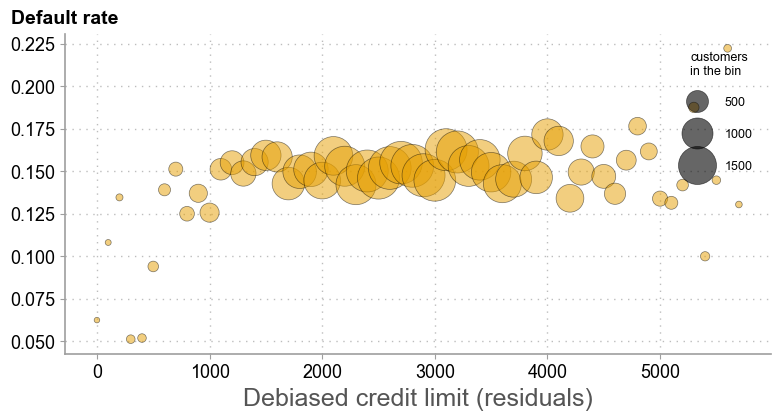

In [220]:
use_plotplainblind("mono")
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf

risk_data = pd.read_csv("./data/risk_data.csv")

# Debiasing step
debiasing_model = smf.ols(
    'credit_limit ~ wage + credit_score1 + credit_score2',
    data=risk_data
).fit()

risk_data_deb = risk_data.assign(
    credit_limit_res=(debiasing_model.resid
                      + risk_data["credit_limit"].mean())
)

fig, ax = plt.subplots(figsize=(8, 4.4))
plt_df = (risk_data_deb
          .assign(size=1)
          .assign(credit_limit_res=lambda d: d["credit_limit_res"].round(-2))
          .groupby("credit_limit_res")
          .agg({"default": "mean", "size": "sum"})
          .query("size>30")
          .reset_index())

sc = ax.scatter(plt_df["credit_limit_res"], plt_df["default"],
           s=plt_df["size"]/2, alpha=0.5, color="#E69F00", edgecolors="black", linewidth=0.5)
ax.set_xlabel("Debiased credit limit (residuals)")
set_top_ylabel(ax, "Default rate", fontsize=14, fontweight="bold")
sizes_handles, sizes_labels = sc.legend_elements(
    prop="sizes", num=4, alpha=0.6, func=lambda s: s * 2)
ax.legend(sizes_handles, sizes_labels, title="customers\nin the bin",
          loc="upper right", framealpha=0.9, labelspacing=1.5,
          borderpad=0.9, handletextpad=1.2, fontsize=9, title_fontsize=9)
plt.tight_layout()

### Debiasing Alone Already Fixes the Bias

Regress the outcome on nothing but the <b style="color:#73000A;">debiased</b> treatment. No controls, no denoising:

$$\texttt{default} \sim \widetilde{\texttt{credit limit}}$$

- The estimate is the same one the full regression gave, to the last decimal
- The confounders are gone from the estimate even though they are not in the model
- The debiasing step already used them
- What is <b style="color:#73000A;">not</b> the same is the standard error. That is what denoising buys, and it comes next

In [221]:
risk_data = pd.read_csv("./data/risk_data.csv")

debiasing_model = smf.ols("credit_limit ~ wage + credit_score1 + credit_score2",
                          data=risk_data).fit()

# the mean is added back only so the residual sits in the original dollar range
risk_data_deb = risk_data.assign(
    credit_limit_res=debiasing_model.resid + risk_data["credit_limit"].mean())

smf.ols("default ~ credit_limit_res", data=risk_data_deb).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.1421,0.005,30.001,0.000,0.133,0.151
credit_limit_res,3.063e-06,1.56e-06,1.957,0.050,-4.29e-09,6.13e-06


### Another Way to Write the Coefficient

Since only the treatment has to be residualized, the coefficient can be written with $T$ cleaned and $Y$ left alone:

$$\beta_1 = \frac{E\big[(T_i - \bar{T})\,y_i\big]}{E\big[(T_i - \bar{T})^2\big]}
\qquad\text{and with controls}\qquad
\beta_1 = \frac{E\big[(T_i - E[T \mid X])\,y_i\big]}{E\big[\operatorname{Var}(T \mid X)\big]}$$

- The numerator: how the outcome moves with the <b style="color:#73000A;">unpredictable part</b> of the treatment
- The denominator: how much the treatment still varies once $X$ is known
- The second form says the answer is weighted by <b style="color:#73000A;">treatment variance</b>
- That returns later, when we ask what regression is averaging

### Why It Works: Denoising

- After debiasing, $\tilde{Y}$ still contains noise from X
- The denoising step regresses Y on X to remove that noise
- The residuals $\tilde{Y} = Y - \hat{E}[Y|X]$ are the "signal" part
- Reduces variance of the estimate (though not bias)

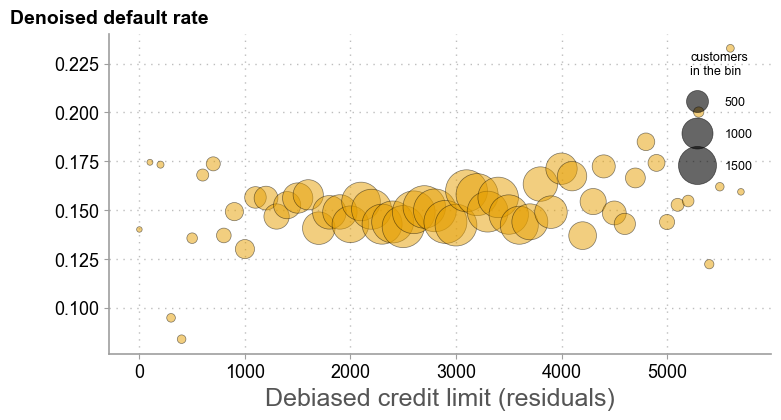

In [222]:
use_plotplainblind("mono")
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf

risk_data = pd.read_csv("./data/risk_data.csv")

# Debiasing
debiasing_model = smf.ols(
    'credit_limit ~ wage + credit_score1 + credit_score2',
    data=risk_data
).fit()

risk_data_deb = risk_data.assign(
    credit_limit_res=(debiasing_model.resid
                      + risk_data["credit_limit"].mean())
)

# Denoising
denoising_model = smf.ols(
    'default ~ wage + credit_score1 + credit_score2',
    data=risk_data_deb
).fit()

risk_data_denoise = risk_data_deb.assign(
    default_res=denoising_model.resid + risk_data_deb["default"].mean()
)

fig, ax = plt.subplots(figsize=(8, 4.4))
plt_df = (risk_data_denoise
          .assign(size=1)
          .assign(credit_limit_res=lambda d: d["credit_limit_res"].round(-2))
          .groupby("credit_limit_res")
          .agg({"default_res": "mean", "size": "sum"})
          .query("size>30")
          .reset_index())

sc = ax.scatter(plt_df["credit_limit_res"], plt_df["default_res"],
           s=plt_df["size"]/2, alpha=0.5, color="#E69F00", edgecolors="black", linewidth=0.5)
ax.set_xlabel("Debiased credit limit (residuals)")
set_top_ylabel(ax, "Denoised default rate", fontsize=14, fontweight="bold")
sizes_handles, sizes_labels = sc.legend_elements(
    prop="sizes", num=4, alpha=0.6, func=lambda s: s * 2)
ax.legend(sizes_handles, sizes_labels, title="customers\nin the bin",
          loc="upper right", framealpha=0.9, labelspacing=1.5,
          borderpad=0.9, handletextpad=1.2, fontsize=9, title_fontsize=9)
plt.tight_layout()

### Where the Standard Error Comes From

$$SE(\hat{\beta}) = \frac{\sigma(\hat{\varepsilon})}{\sigma(\tilde{T})\,\sqrt{n - DF}}$$

- $\sigma(\hat{\varepsilon})$: how much of the outcome the model still cannot explain
- $\sigma(\tilde{T})$: how much the treatment varies once the controls are accounted for
- $DF$: the number of parameters the model spent
- Denoising works on the numerator. Splitting the outcome's variance, $\sigma^2_Y = \sigma^2_{\text{explained}} + \sigma^2_{\text{residual}}$, the controls move variance out of the second piece
- The formula reproduces what statsmodels prints:

In [223]:
risk_data = pd.read_csv("./data/risk_data.csv")

model_se = smf.ols("default ~ wage + credit_score1 + credit_score2",
                   data=risk_data).fit()
print("SE from statsmodels:", model_se.bse["wage"])

# rebuild it: residual sd, over treatment-residual sd, over sqrt(n - parameters)
aux = smf.ols("wage ~ credit_score1 + credit_score2", data=risk_data).fit()
se_formula = (np.std(model_se.resid)
              / (np.std(aux.resid) * np.sqrt(len(risk_data) - 4)))
print("SE from the formula:", se_formula)

SE from statsmodels: 5.364242347548209e-06
SE from the formula: 5.364242347548201e-06


### Anatomy of Standard Errors: What Shrinks Them

$$SE(\hat{\beta}_T) = \frac{\sigma_{\text{residual}}}{\sigma_T \sqrt{n}}$$

Three levers pull down the standard error:

1. <b style="color:#73000A;">Smaller outcome noise</b> $\sigma_{\text{residual}}$: control for good predictors of Y
2. <b style="color:#73000A;">Larger treatment variance</b> $\sigma_T$: more spread in your treatment
3. <b style="color:#73000A;">Larger sample size</b> $n$: more data always helps

### Aside: Standard Errors with a Continuous Treatment

$$SE(\hat{\beta}) \approx \frac{\sigma_{\text{resid}}}{\sigma_T \sqrt{n}}$$

- Precision comes from three places: less residual noise, <b style="color:#73000A;">more treatment variation</b>, more data
- The experiments lecture's binary formula is this same expression with $\mathrm{Var}(T) = p(1-p)$
- Design lesson: an experiment that barely varies the treatment cannot measure it, no matter how large $n$ grows

### Heteroskedasticity-Robust Standard Errors

The standard error formula assumed the noise has the same spread everywhere. Often it does not:

- Customers on small credit lines behave alike: they default rarely, and predictably
- Customers on the largest lines are all over the place, so the outcome is far noisier up there
- The estimate is untouched by this. The <b style="color:#73000A;">standard error</b> is what breaks, and it usually comes out too small

<b style="color:#73000A;">Fix</b>: robust standard errors, `cov_type="HC1"` in `statsmodels`. Below, the honest standard error on the treatment is about a third wider.

In [224]:
np.random.seed(42)
n = 2000

credit_limit = np.random.uniform(200, 8500, n)

# default behaviour is far more variable among customers with the biggest lines
spread = (credit_limit / 2000) ** 3
default = 0.2 + 0.00001 * credit_limit + 0.01 * np.random.normal(0, 1, n) * spread

d = pd.DataFrame({"default": default, "credit_limit": credit_limit})
m = smf.ols("default ~ credit_limit", data=d).fit()
robust = m.get_robustcov_results(cov_type="HC1")

pd.DataFrame({"standard SE": ["%.3e" % v for v in m.bse],
              "robust SE (HC1)": ["%.3e" % v for v in robust.bse],
              "robust / standard": (robust.bse / m.bse).round(2)},
             index=m.params.index).loc[["credit_limit"]]

,standard SE,robust SE (HC1),robust / standard
credit_limit,2.605e-06,3.429e-06,1.32


### Final Outcome Model: FWL in Action

- Regress denoised Y on debiased T
- Slope estimate = coefficient on T in the full model
- Same point estimate as the big regression
- But now we understand the three components: debiasing, denoising, estimation
- One warning: debiasing and denoising both center their variables, so the <b style="color:#73000A;">intercept lands on zero</b>. Fine when you want a slope, wrong if you want a predicted level

In [225]:
model_w_orthogonal = smf.ols('default_res ~ credit_limit_res',
                             data=risk_data_denoise).fit()

model_w_orthogonal.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.1421,0.005,30.458,0.000,0.133,0.151
credit_limit_res,3.063e-06,1.54e-06,1.987,0.047,4.17e-08,6.08e-06


## Regression as an Outcome Model

Everything so far cleaned the <b style="color:#73000A;">treatment</b>. There is a second way to use the same regression: model the <b style="color:#73000A;">outcome</b> and fill in what you never saw.

Take a binary treatment. Fit $Y$ on $X$ among the <b style="color:#73000A;">untreated only</b>, and call that fit $\hat{\mu}_0(X)$. It estimates $E[Y_0 \mid X]$.

$$ATT = \frac{1}{N_1}\sum_i \mathbf{1}\{T_i = 1\}\big(Y_i - \hat{\mu}_0(X_i)\big)$$

- Every treated unit is compared with what the control model says it would have done untreated
- $N_1$ is the number of treated units, and $\mathbf{1}\{\cdot\}$ is 1 when the condition holds
- The counterfactual is <b style="color:#73000A;">imputed</b> by the model, never observed

### Impute Both Sides and You Have the ATE

Fit $\hat{\mu}_1$ on the treated as well, and every unit has both potential outcomes:

$$ATE = \frac{1}{N}\sum_i \big(\hat{\mu}_1(X_i) - \hat{\mu}_0(X_i)\big)$$

- Which is the same number as regressing $Y$ on $X$ <b style="color:#73000A;">and</b> $T$ and reading the coefficient on $T$
- Or impute only what is actually missing, and keep the real outcome where you have it:

$$ATE = \frac{1}{N}\sum_i \Big( \mathbf{1}\{T_i{=}1\}\big[Y_i - \hat{\mu}_0(X_i)\big] + \mathbf{1}\{T_i{=}0\}\big[\hat{\mu}_1(X_i) - Y_i\big] \Big)$$

- With a continuous treatment there is no pair to impute. The model fills in the whole <b style="color:#73000A;">response curve</b> $Y(t)$, which is why the line's slope is the effect

### Double Robustness

- <b style="color:#73000A;">Orthogonalization</b> works if you model the treatment well: $E[T \mid X]$
- <b style="color:#73000A;">Imputation</b> works if you model the outcome well: $E[Y \mid X]$
- Regression does both at once, so getting <b style="color:#73000A;">either one</b> right is enough for the estimate to survive
- That property is called <b style="color:#73000A;">double robustness</b>, and we build the estimator that uses it when we reach propensity scores and double machine learning

### Example: Marketing Mix Modeling

- Regress sales on marketing spend per channel, plus seasonality, price, holidays
- Read each channel's coefficient as its contribution to sales
- Pure regression-as-outcome-model, a workhorse in industry
- Causal only if the controls close the back doors: the same warning as always

## Positivity and Extrapolation

- Regression assumes linearity holds everywhere
- If treatment only takes certain values in the data, extrapolation is risky
- Positivity: T must vary at all levels of X for identification
- Violating positivity means trusting the parametric model, which may fail

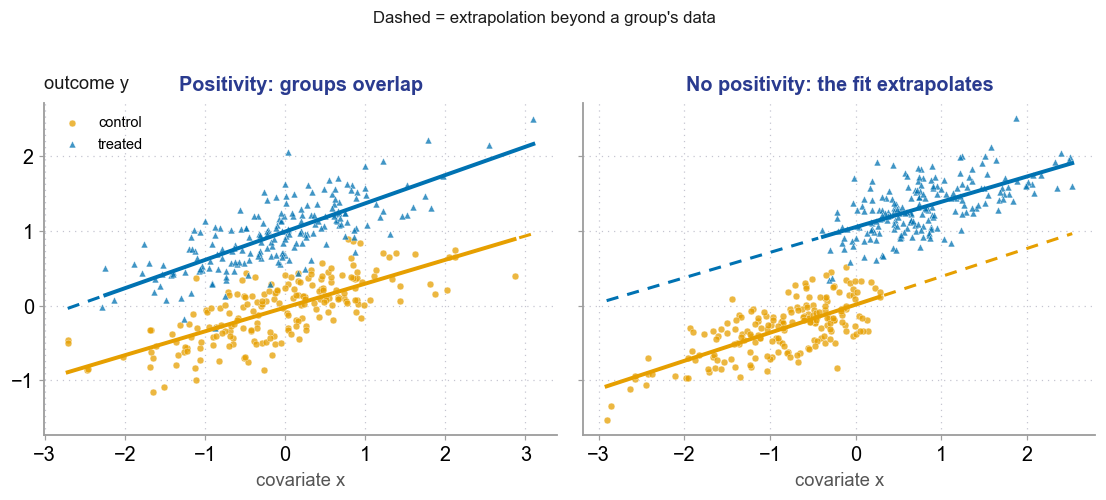

In [226]:
chh.fig_positivity()

### Extrapolation: The Line Keeps Climbing

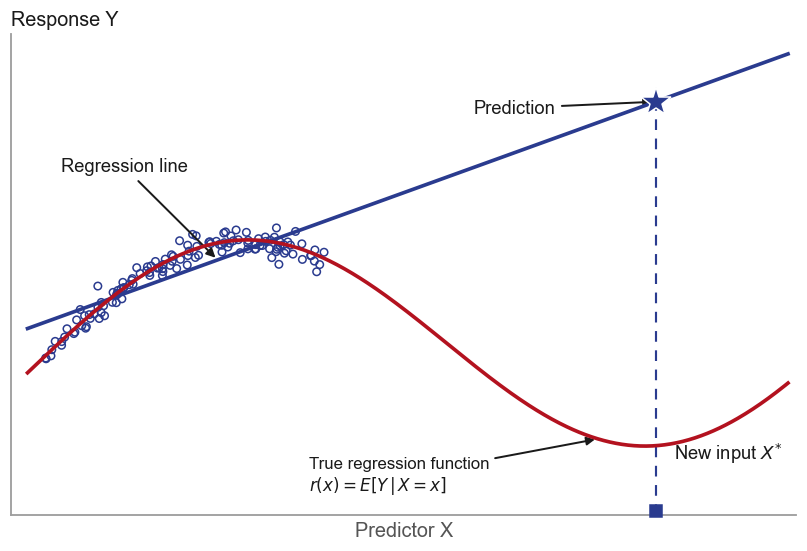

In [227]:
chh.fig_extrapolation()

### Extrapolation, Illustrated

*xkcd 605, "Extrapolating," by Randall Munroe (CC BY-NC 2.5)*

In [228]:
from IPython.display import Image
Image(url="https://imgs.xkcd.com/comics/extrapolating.png")

## Nonlinearities in Linear Regression

- Real relationships often have curvature
- Example: credit lines on spend is concave, not linear
- Solution: transform the treatment (sqrt, log) to linearize
- After transformation, apply FWL as before

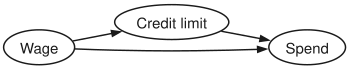

In [229]:
chh.draw_dag([("Wage", "Credit limit"), ("Wage", "Spend"), ("Credit limit", "Spend")])

### Spotting Nonlinearity

- Plot outcome vs treatment, stratified by confounder groups
- If curves bend, relationship is nonlinear
- Larger credit lines have diminishing returns on spend

In [230]:
spend_data = pd.read_csv("./data/spend_data.csv")

spend_data.head()

,wage,educ,exper,married,credit_score1,credit_score2,credit_limit,spend
0,950.0,11,16,1,500.0,518.0,3200.0,3848
1,780.0,11,7,1,414.0,429.0,1700.0,3144
2,1230.0,14,9,1,586.0,571.0,4200.0,4486
3,1040.0,15,8,1,379.0,411.0,1500.0,3327
4,1000.0,16,1,1,379.0,518.0,1800.0,3508


### Spotting Nonlinearity

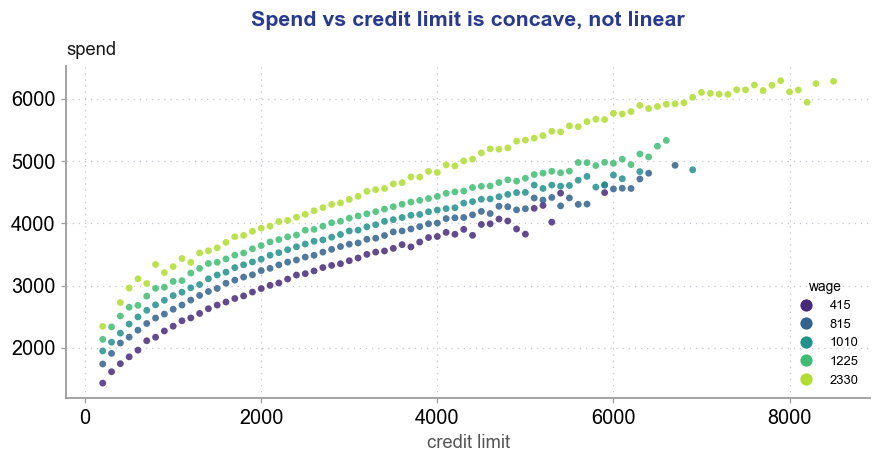

In [231]:
chh.fig_nonlinearity_spend()

### Linearizing the Treatment

- Apply sqrt, log, or other concave function to T
- Refits spend ~ sqrt(credit_limit)
- Now the relationship is approximately linear
- Much cleaner fit across wage groups

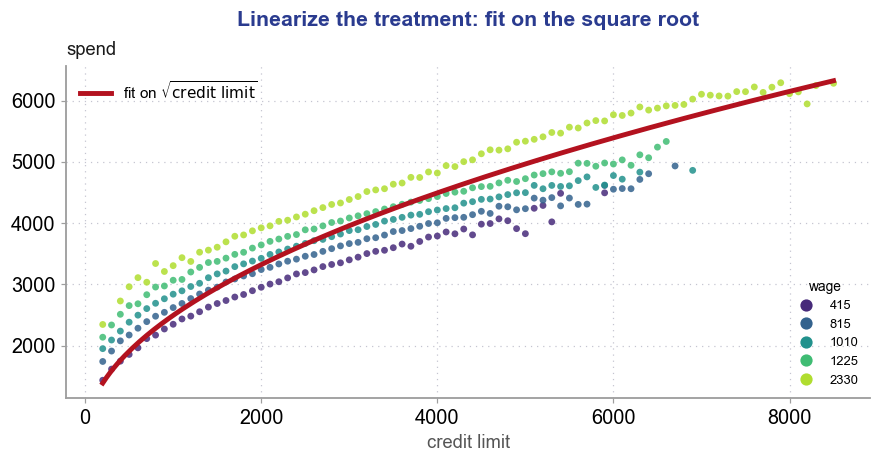

In [232]:
chh.fig_linearize_treatment()

### The Transformation Alone Is Not Enough

- Taking the square root fixed the <b style="color:#73000A;">shape</b>. It did nothing about the <b style="color:#73000A;">confounding</b>
- Wage still causes both the limit and the spending, so the naive fit is biased upward
- Put wage in the model and the effect drops from about <b style="color:#73000A;">63</b> to about <b style="color:#73000A;">44</b> per unit of $\sqrt{\text{limit}}$
- Two separate problems, two separate fixes, and you need both

In [233]:
spend_data = pd.read_csv("./data/spend_data.csv")

naive = smf.ols("spend ~ np.sqrt(credit_limit)", data=spend_data).fit()
with_wage = smf.ols("spend ~ np.sqrt(credit_limit) + wage", data=spend_data).fit()

pd.DataFrame({
    "model": ["spend ~ sqrt(limit)", "spend ~ sqrt(limit) + wage"],
    "effect per sqrt-dollar": [naive.params["np.sqrt(credit_limit)"],
                               with_wage.params["np.sqrt(credit_limit)"]],
    "std err": [naive.bse["np.sqrt(credit_limit)"],
                with_wage.bse["np.sqrt(credit_limit)"]],
}).round(4)

,model,effect per sqrt-dollar,std err
0,spend ~ sqrt(limit),63.2525,0.1218
1,spend ~ sqrt(limit) + wage,43.8504,0.0652


### Nonlinear FWL

- Debiasing: regress F(T) on X, get residuals $\widetilde{F(T)}$
- Denoising: regress Y on X, get residuals $\tilde{Y}$
- Outcome: regress $\tilde{Y}$ on $\widetilde{F(T)}$
- Same three steps, but with transformed treatment

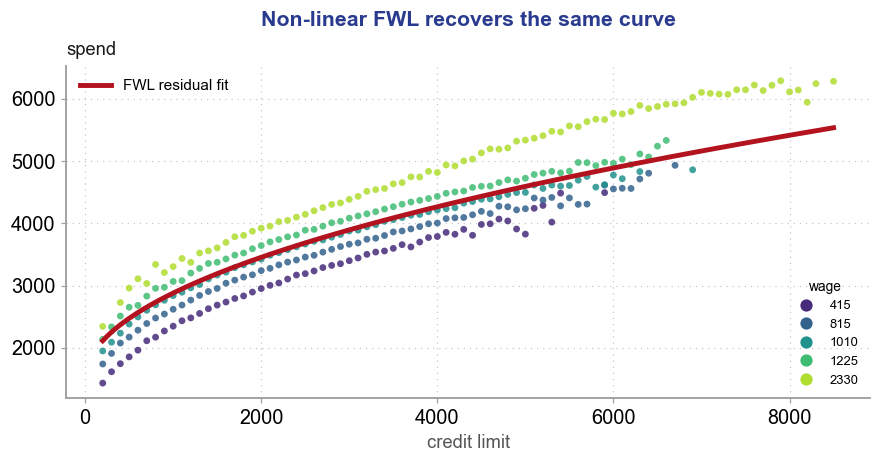

In [234]:
chh.fig_nonlinear_fwl()

In [235]:
spend_data = pd.read_csv("./data/spend_data.csv")

# 1. linearize, 2. debias the transformed treatment, 3. denoise the outcome
debias = smf.ols("np.sqrt(credit_limit) ~ wage", data=spend_data).fit()
denoise = smf.ols("spend ~ wage", data=spend_data).fit()

d = spend_data.assign(
    sqrt_limit_deb=debias.resid + np.sqrt(spend_data["credit_limit"]).mean(),
    spend_den=denoise.resid + spend_data["spend"].mean())

fwl = smf.ols("spend_den ~ sqrt_limit_deb", data=d).fit()
full = smf.ols("spend ~ np.sqrt(credit_limit) + wage", data=spend_data).fit()

print(f"three steps, nonlinear : {fwl.params['sqrt_limit_deb']:.4f}")
print(f"one big regression     : {full.params['np.sqrt(credit_limit)']:.4f}")

three steps, nonlinear : 43.8504
one big regression     : 43.8504


## Regression for Dummies

Everything so far rests on a claim you cannot test: that the controls close <b style="color:#73000A;">every</b> back door.

- The honest reply to an untestable assumption is to stop assuming and start randomizing
- But randomizing credit limits means handing large lines to the customers most likely to default
- The cost is not hypothetical. It is defaults the bank does not recover
- The compromise: randomize <b style="color:#73000A;">inside</b> groups. Cheap enough to run, and the independence assumption becomes something you designed rather than hoped for

### A Conditionally Random Experiment

- Sort customers into risk buckets by `credit_score1`: 0 to 200, 200 to 400, and so on
- Inside a bucket, draw the credit limit <b style="color:#73000A;">at random</b>
- Draw from a different distribution in each bucket: lower average lines for risky buckets, higher for safe ones
- The bank's exposure stays bounded, and the limit is random <b style="color:#73000A;">given the bucket</b>
- That is the conditional independence assumption, this time by construction rather than by assertion

In [236]:
risk_data_rnd = pd.read_csv("./data/risk_data_rnd.csv")
risk_data_rnd.head()

,wage,educ,exper,married,credit_score1,credit_score2,credit_score1_buckets,credit_limit,default
0,890.0,11,16,1,490.0,500.0,400,5400.0,0
1,670.0,11,7,1,196.0,481.0,200,3800.0,0
2,1220.0,14,9,1,392.0,611.0,400,5800.0,0
3,1210.0,15,8,1,627.0,519.0,600,6500.0,0
4,900.0,16,1,1,275.0,519.0,200,2100.0,0


### A Different Distribution of Lines in Every Bucket

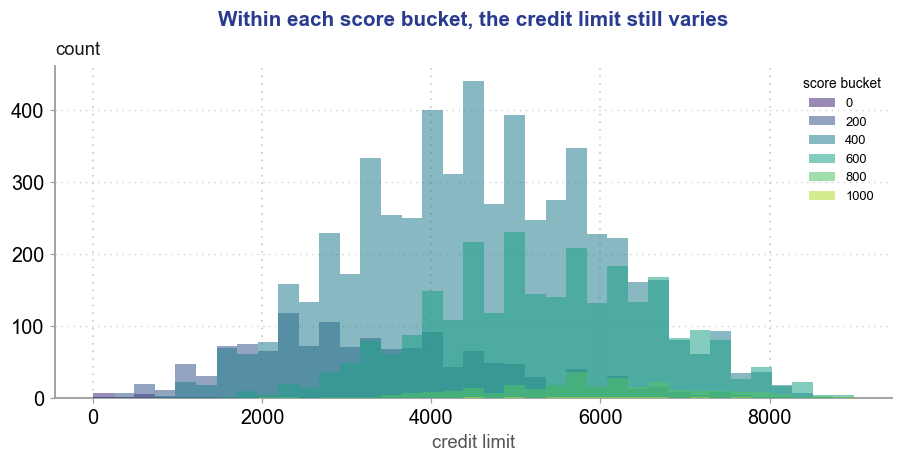

In [237]:
chh.fig_conditional_random()

### Two Rules for Designing One

- <b style="color:#73000A;">Fewer groups is easier.</b> Five buckets here, not fifty. Every extra group is another treatment distribution to keep track of
- <b style="color:#73000A;">More overlap is easier.</b> If the risky bucket can never receive a high limit, nothing in the data says what a high limit would have done to them
- The second rule is <b style="color:#73000A;">positivity</b>, stated as a design choice
- Push both rules to their limit and you get back the fully random experiment: the easiest to read and the most expensive to run
- Every stratified design is a chosen point on that trade

### Now the Naive Regression Gets the Sign Wrong

Run the simple regression on this experimental data, with no controls:

- The coefficient comes out <b style="color:#73000A;">negative</b> again: more credit, less default
- And the treatment really was randomized, so what happened?
- It was randomized <b style="color:#73000A;">within</b> buckets, and the buckets were handed different distributions on purpose
- Random inside groups is not random overall. Pool the groups and the design's own structure becomes confounding

In [238]:
risk_data_rnd = pd.read_csv("./data/risk_data_rnd.csv")

smf.ols("default ~ credit_limit", data=risk_data_rnd).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.1369,0.009,15.081,0.000,0.119,0.155
credit_limit,-9.344e-06,1.85e-06,-5.048,0.000,-1.3e-05,-5.72e-06


### Dummies, or One-Hot Encoding

A dummy is a 0/1 column for one group: 1 if the customer is in it, 0 otherwise. If you came from machine learning you know this as <b style="color:#73000A;">one-hot encoding</b>. Same thing, different name.

- Each customer is in exactly one bucket, so exactly one dummy is 1 across the row
- We drop the first bucket's column. With an intercept and <b style="color:#73000A;">all</b> the dummies, the columns are redundant: knowing the others tells you the one you dropped
- The dropped group becomes the <b style="color:#73000A;">baseline</b>, and the intercept is its level
- Every other dummy's coefficient reads as a gap from that baseline

In [239]:
risk_data_rnd = pd.read_csv("./data/risk_data_rnd.csv")

risk_data_dummies = risk_data_rnd.join(
    pd.get_dummies(risk_data_rnd["credit_score1_buckets"], prefix="sb",
                   drop_first=True).astype(int))

risk_data_dummies[["credit_score1_buckets", "credit_limit",
                   "sb_400", "sb_600", "sb_800", "sb_1000"]].head()

,credit_score1_buckets,credit_limit,sb_400,sb_600,sb_800,sb_1000
0,400,5400.0,1,0,0,0
1,200,3800.0,0,0,0,0
2,400,5800.0,1,0,0,0
3,600,6500.0,0,1,0,0
4,200,2100.0,0,0,0,0


### The Same Model, Written Two Ways

Add the dummies to the regression and the estimate turns <b style="color:#73000A;">positive</b>, which is what we expected all along.

- Spelling out the dummy columns and letting `statsmodels` do it with `C(...)` are the same model
- Same coefficient, same standard error, one line of typing instead of five
- Doing it by hand once is worth it. Not every tool you meet will have a `C(...)`

In [240]:
risk_data_rnd = pd.read_csv("./data/risk_data_rnd.csv")
risk_data_dummies = risk_data_rnd.join(
    pd.get_dummies(risk_data_rnd["credit_score1_buckets"], prefix="sb",
                   drop_first=True).astype(int))

by_hand = smf.ols("default ~ credit_limit + sb_200 + sb_400 + sb_600 + sb_800 + sb_1000",
                  data=risk_data_dummies).fit()
shortcut = smf.ols("default ~ credit_limit + C(credit_score1_buckets)",
                   data=risk_data_rnd).fit()

pd.DataFrame({
    "model": ["dummies spelled out", "C(credit_score1_buckets)"],
    "credit_limit coef": ["%.4e" % by_hand.params["credit_limit"],
                          "%.4e" % shortcut.params["credit_limit"]],
    "std err": ["%.3e" % by_hand.bse["credit_limit"],
                "%.3e" % shortcut.bse["credit_limit"]],
})

,model,credit_limit coef,std err
0,dummies spelled out,4.6519e-06,2.018e-06
1,C(credit_score1_buckets),4.6519e-06,2.018e-06


### One Intercept per Group, One Slope for Everyone

- The dummies gave each bucket its own <b style="color:#73000A;">height</b>
- They did not give any bucket its own <b style="color:#73000A;">slope</b>. There is one `credit_limit` coefficient in the model, and every group is fitted with it
- So the picture is six parallel lines, one per risk bucket
- So what if the effect really does differ from bucket to bucket?

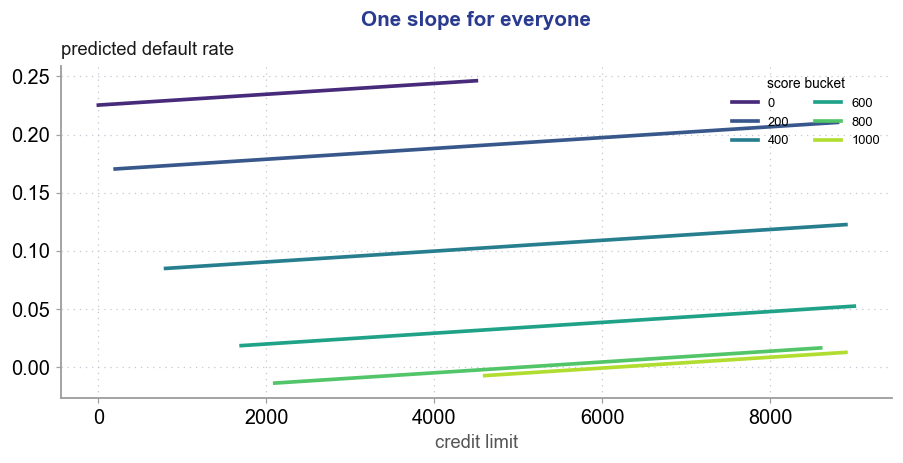

In [241]:
chh.fig_fitted_by_group(saturated=False)

### Saturated Model: Interacting Treatment and Groups

- Fully flexible model: estimate a separate slope for each group
- Use interaction terms: outcome ~ treatment * groups
- This estimates the ATE in each group separately
- Test heterogeneity: are the slopes different?

In [242]:
model = smf.ols("default ~ credit_limit * C(credit_score1_buckets)",
                data=risk_data_rnd).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.3137,0.077,4.086,0.000,0.163,0.464
C(credit_score1_buckets)[T.200],-0.1521,0.079,-1.926,0.054,-0.307,0.003
C(credit_score1_buckets)[T.400],-0.2339,0.078,-3.005,0.003,-0.386,-0.081
C(credit_score1_buckets)[T.600],-0.2957,0.080,-3.690,0.000,-0.453,-0.139
C(credit_score1_buckets)[T.800],-0.3227,0.111,-2.919,0.004,-0.539,-0.106
C(credit_score1_buckets)[T.1000],-0.3137,0.428,-0.733,0.464,-1.153,0.525
credit_limit,-7.072e-05,4.45e-05,-1.588,0.112,-0.000,1.66e-05
credit_limit:C(credit_score1_buckets)[T.200],7.769e-05,4.48e-05,1.734,0.083,-1.01e-05,0.000
credit_limit:C(credit_score1_buckets)[T.400],7.565e-05,4.46e-05,1.696,0.090,-1.18e-05,0.000
credit_limit:C(credit_score1_buckets)[T.600],7.398e-05,4.47e-05,1.655,0.098,-1.37e-05,0.000


### Reading a Saturated Model

Every interaction coefficient is a <b style="color:#73000A;">difference from the baseline bucket</b>, not an effect. To get a bucket's own slope, add its interaction to the `credit_limit` coefficient.

- Do that for all six buckets and you get six slopes
- Run six <b style="color:#73000A;">separate</b> regressions, one per bucket, and you get the same six numbers
- The saturated model is not an approximation to running them separately. It is the same six regressions, written in one line

In [243]:
risk_data_rnd = pd.read_csv("./data/risk_data_rnd.csv")

# six separate regressions, one inside each bucket
def regress(df, t, y):
    return smf.ols(f"{y} ~ {t}", data=df).fit().params[t]

separate = (risk_data_rnd
            .groupby("credit_score1_buckets")
            .apply(regress, y="default", t="credit_limit"))

# the saturated model: baseline slope plus each interaction
sat = smf.ols("default ~ credit_limit * C(credit_score1_buckets)",
              data=risk_data_rnd).fit()
from_saturated = (sat.params[sat.params.index.str.contains("credit_limit:")]
                  + sat.params["credit_limit"])

pd.DataFrame({"one regression per bucket": separate.round(9).values,
              "read off the saturated model":
                  [round(sat.params["credit_limit"], 9)]
                  + list(from_saturated.round(9).values)},
             index=[int(b) for b in separate.index])

,one regression per bucket,read off the saturated model
0,-0.000071,-0.000071
200,0.000007,0.000007
400,0.000005,0.000005
600,0.000003,0.000003
800,0.000002,0.000002
1000,0.000000,0.000000


### Every Bucket Gets Its Own Slope

- Six lines, six tilts. The parallel lines from a moment ago have come apart
- One of them slopes the <b style="color:#73000A;">wrong way</b>: in the riskiest bucket, more credit appears to mean less default
- That slope is not significant. It is a thin group and this is noise
- Which is the cost of a saturated model: one more parameter per group, and more variance in every estimate
- Flexibility costs degrees of freedom

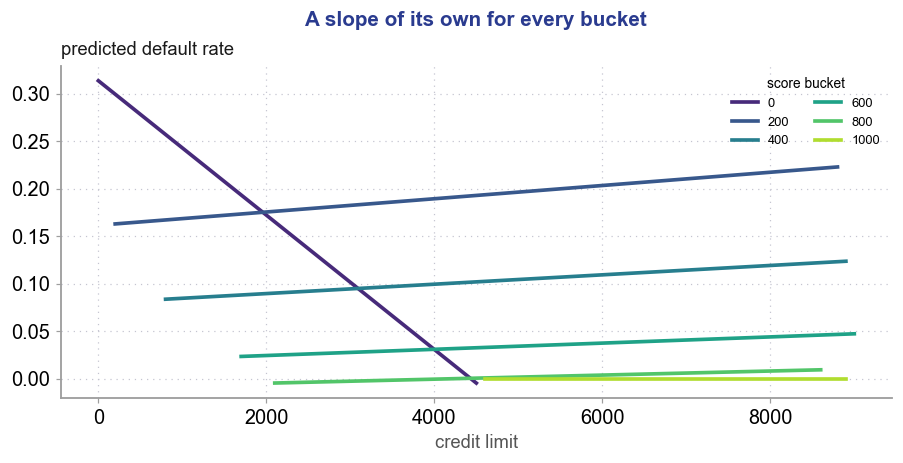

In [244]:
chh.fig_fitted_by_group(saturated=True)

### So What Does the Pooled Slope Average?

Two ways to combine six group effects into one number:

- Estimate the effect in each bucket, then average with <b style="color:#73000A;">sample size</b> as the weight. The obvious choice
- Or put the dummies in and let the regression pool for you

They do not agree, and the gap is not a rounding error. Regression is not weighting by sample size.

- It weights each group by the <b style="color:#73000A;">variance of the treatment</b> inside that group
- Which the alternative formula told us already: the denominator was $E[\operatorname{Var}(T \mid X)]$

In [245]:
np.random.seed(123)

# group 1: 1000 units, true effect 1, treatment sd 1
t1 = np.random.normal(0, 1, 1000)
df1 = pd.DataFrame(dict(t=t1, y=1 * t1, g=1))

# group 2: 500 units, true effect 2, treatment sd 2
t2 = np.random.normal(0, 2, 500)
df2 = pd.DataFrame(dict(t=t2, y=2 * t2, g=2))

df = pd.concat([df1, df2])

by_group = df.groupby("g").apply(lambda d: smf.ols("y ~ t", data=d).fit().params["t"])
sizes = df.groupby("g").size()
size_weighted = (by_group * sizes).sum() / sizes.sum()

pooled = smf.ols("y ~ t + C(g)", data=df).fit().params["t"]

print(f"effect in group 1 (n=1000, sd(t)=1): {by_group[1]:.2f}")
print(f"effect in group 2 (n=500,  sd(t)=2): {by_group[2]:.2f}")
print(f"weighted by sample size            : {size_weighted:.2f}")
print(f"what the regression reports        : {pooled:.2f}")

effect in group 1 (n=1000, sd(t)=1): 1.00
effect in group 2 (n=500,  sd(t)=2): 2.00
weighted by sample size            : 1.33
what the regression reports        : 1.63


### Why Variance, and Not Size

$$ATE = E\Big\{ \Big(\tfrac{\partial}{\partial t}E[Y_i \mid T{=}t, \text{Group}_i]\Big)\, w(\text{Group}_i) \Big\}
\qquad w(\text{Group}) \propto \sigma^2(T \mid \text{Group})$$

- Regression prefers the groups where the treatment moved a lot, and it is not being unreasonable
- Where the treatment barely varies, that group tells you very little about the effect, so it gets a small vote
- If you want <b style="color:#73000A;">size</b> weights instead, run the groups separately and average them yourself. That is a choice, and it is yours to make
- The 2020s difference-in-differences literature is largely about regression weighting effects in ways nobody intended

## De-Meaning and Fixed Effects

With many groups, dummies get expensive: a thousand groups means a thousand mostly-zero columns to build and invert. FWL offers a shortcut.

- Step 1 of FWL says: predict the treatment from the controls and keep the residual
- When the controls are group dummies, that prediction is just the <b style="color:#73000A;">group's average treatment</b>
- So the residual is $T_i - \bar{T}_{g(i)}$, each unit minus its own group's mean
- Regress the outcome on that and you get the dummy model's estimate, without ever building a dummy
- Subtracting the group mean is called <b style="color:#73000A;">de-meaning</b>, and controlling this way is called <b style="color:#73000A;">fixed effects</b>

In [246]:
risk_data_fe = risk_data_rnd.assign(
    credit_limit_avg = lambda d: (d
                                  .groupby("credit_score1_buckets")
                                  ["credit_limit"].transform("mean"))
)

In [247]:
# the bucket means we subtract when we de-mean
risk_data_rnd.groupby("credit_score1_buckets")["credit_limit"].mean().round(0)

credit_score1_buckets
0       1173.0
200     3369.0
400     4575.0
600     5364.0
800     5813.0
1000    6180.0
Name: credit_limit, dtype: float64

## De-Meaning and Fixed Effects

In [248]:
import pandas as pd, statsmodels.formula.api as smf
# de-meaning the treatment within buckets gives the SAME estimate as bucket dummies
demean  = smf.ols("default ~ I(credit_limit - credit_limit_avg)", data=risk_data_fe).fit()
dummies = smf.ols("default ~ credit_limit + C(credit_score1_buckets)", data=risk_data_fe).fit()

pd.DataFrame([
    dict(method="de-mean within bucket",
         coef_per_1k=demean.params.iloc[1] * 1000, std_err_per_1k=demean.bse.iloc[1] * 1000),
    dict(method="bucket dummies (fixed effects)",
         coef_per_1k=dummies.params["credit_limit"] * 1000,
         std_err_per_1k=dummies.bse["credit_limit"] * 1000),
]).round(4)

,method,coef_per_1k,std_err_per_1k
0,de-mean within bucket,0.0047,0.002
1,bucket dummies (fixed effects),0.0047,0.002


### Mundlak's Version of the Same Trick

Rather than subtracting the group mean, put it in the model as a regressor:

$$\texttt{default} \sim \texttt{credit limit} + \overline{\texttt{credit limit}}_{\,g}$$

- Regression then residualizes the treatment against the group means on its own, and the estimate matches again
- Three routes, one number: dummies, de-meaning, and Mundlak (1978)
- The third has a bonus: the group means stay in the output, so you can see how much of the treatment is <b style="color:#73000A;">between</b> groups rather than within

In [249]:
risk_data_rnd = pd.read_csv("./data/risk_data_rnd.csv")
risk_data_fe = risk_data_rnd.assign(
    credit_limit_avg=lambda d: d.groupby("credit_score1_buckets")
                                ["credit_limit"].transform("mean"))

rows = [
    ("bucket dummies",
     "default ~ credit_limit + C(credit_score1_buckets)", "credit_limit"),
    ("de-meaned treatment",
     "default ~ I(credit_limit - credit_limit_avg)",
     "I(credit_limit - credit_limit_avg)"),
    ("Mundlak: add the group mean",
     "default ~ credit_limit + credit_limit_avg", "credit_limit"),
]
fits = [(name, smf.ols(f, data=risk_data_fe).fit(), term) for name, f, term in rows]

pd.DataFrame({"approach": [n for n, _, _ in fits],
              "effect of the treatment": ["%.4e" % m.params[t] for _, m, t in fits],
              "std err": ["%.3e" % m.bse[t] for _, m, t in fits]})

,approach,effect of the treatment,std err
0,bucket dummies,4.6519e-06,2.018e-06
1,de-meaned treatment,4.6519e-06,2.047e-06
2,Mundlak: add the group mean,4.6519e-06,2.018e-06


## When Regression Hurts

- Adding controls is not free and not always safe
- <b style="color:#73000A;">Omit</b> a confounder: bias, with a known sign and size
- <b style="color:#73000A;">Add</b> the wrong control: more variance, or brand new bias
- The graph decides which. The regression output cannot tell you

## Omitted Variable Bias: Confounding Through Regression

- Bias formula: $\text{bias} = \beta_{omitted} \cdot \delta_{omitted}$
- $\beta_{omitted}$: effect of omitted variable on outcome
- $\delta_{omitted}$: effect of omitted variable on treatment
- If you omit a confounder, bias = product of these two paths

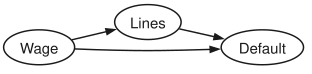

In [250]:
chh.draw_dag([("Wage", "Lines"), ("Wage", "Default"), ("Lines", "Default")])

### Short and Long Regression Algebra

When you omit a confounder from your regression, here's what happens algebraically.

<b style="color:#73000A;">Short model</b> (omitting confounder W):
$$\hat{\beta}_T^{\text{short}} = \frac{\text{Cov}(Y, T)}{\text{Var}(T)}$$

<b style="color:#73000A;">Long model</b> (including confounder W):
$$\hat{\beta}_T^{\text{long}} = \frac{\text{Cov}(Y, \tilde{T})}{\text{Var}(\tilde{T})}$$

where $\tilde{T} = T - E[T|W]$ is treatment residualized on the confounder.

The difference between them is the omitted variable bias.

The bias in the short model comes from this relationship:
$$\hat{\beta}_T^{\text{short}} = \hat{\beta}_T^{\text{long}} + \underbrace{\delta_W \cdot \beta_W}_{\text{OVB}}$$

where:
- $\delta_W$ = coefficient from regressing W on T
- $\beta_W$ = true effect of W on Y (from the long model)

Once you know these two quantities, you know exactly how much bias you incurred.

### The Bias Term, Measured

Run the two regressions the formula names. The bias it predicts is <b style="color:#73000A;">exactly</b> the gap between the short and long models:

$$\underbrace{\frac{\operatorname{Cov}(T, Y)}{\operatorname{Var}(T)}}_{\text{short}}
= \underbrace{\tau}_{\text{long}} + \underbrace{\beta_{\text{omitted}}'\,\delta_{\text{omitted}}}_{\text{bias}}$$

- $\beta_{\text{omitted}}$: what wage does to default, from the long model
- $\delta_{\text{omitted}}$: what credit limit predicts about wage, from a regression of the omitted variable on the treatment
- Multiply, add to the long estimate, and you land on the short one to the last decimal

In [251]:
risk_data = pd.read_csv("./data/risk_data.csv")

short = smf.ols("default ~ credit_limit", data=risk_data).fit()
long_ = smf.ols("default ~ credit_limit + wage", data=risk_data).fit()
omitted = smf.ols("wage ~ credit_limit", data=risk_data).fit()   # the omitted variable on T

rebuilt = long_.params["credit_limit"] + long_.params["wage"] * omitted.params["credit_limit"]

print(f"short model coefficient        : {short.params['credit_limit']:.6e}")
print(f"long + (beta_wage * delta_wage): {rebuilt:.6e}")

short model coefficient        : -2.401962e-05
long + (beta_wage * delta_wage): -2.401962e-05


### Numeric Example: Wage Confounding

Suppose you want to estimate the effect of education on earnings, but you omit ability.

<b style="color:#73000A;">The true model</b> (if you could measure ability):
- Each year of education raises earnings by $2000
- Each unit of ability raises earnings by $5000
- High ability people get more education (correlation = 0.4)

<b style="color:#73000A;">What happens in the short model</b>?

In [252]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

np.random.seed(42)
n = 1000

# Generate confounded data
ability = np.random.normal(0, 1, n)
education = 2 + 0.4 * ability + np.random.normal(0, 0.5, n)
earnings = 20000 + 2000 * education + 5000 * ability + np.random.normal(0, 1000, n)

data = pd.DataFrame({'education': education, 'ability': ability, 'earnings': earnings})

# Short model (omitting ability): biased
short_model = smf.ols('earnings ~ education', data=data).fit()
print("SHORT MODEL (omitting ability):")
print(f"Education coefficient: ${short_model.params['education']:.0f}")

# Long model (including ability): unbiased
long_model = smf.ols('earnings ~ education + ability', data=data).fit()
print("LONG MODEL (including ability):")
print(f"Education coefficient: ${long_model.params['education']:.0f}")
print(f"Ability coefficient: ${long_model.params['ability']:.0f}")

delta_w = smf.ols('ability ~ education', data=data).fit().params['education']
beta_w = long_model.params['ability']
bias = delta_w * beta_w

print(f"BIAS DECOMPOSITION:")
print(f"delta_W: {delta_w:.3f}")
print(f"beta_W: ${beta_w:.0f}")
print(f"Bias = {delta_w:.3f} * {beta_w:.0f} = ${bias:.0f}")
print(f"Difference: ${short_model.params['education'] - long_model.params['education']:.0f}")

SHORT MODEL (omitting ability):
Education coefficient: $6716
LONG MODEL (including ability):
Education coefficient: $1980
Ability coefficient: $5030
BIAS DECOMPOSITION:
delta_W: 0.942
beta_W: $5030
Bias = 0.942 * 5030 = $4736
Difference: $4736


Predicted bias sign: ability raises both education and earnings, so the short model is **upward biased**. The short coefficient is roughly $4,000, the true effect is $2,000.

## Neutral Controls

- A neutral control affects outcome but not treatment assignment
- Example: credit_score2 in a credit-scoring bucket experiment
- Adding neutral controls reduces variance (denoising)
- Does not reduce bias, but improves precision
- Tech companies sell this as <b style="color:#73000A;">CUPED</b>: in a clean A/B test there is no bias to remove, so all it does is denoise, and the experiment needs fewer users to reach the same precision

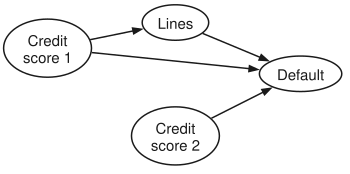

In [253]:
chh.draw_dag([("Credit\nscore 1", "Lines"), ("Credit\nscore 1", "Default"),
              ("Credit\nscore 2", "Default"), ("Lines", "Default")])

## Neutral Controls

In [254]:
import pandas as pd, statsmodels.formula.api as smf
d = pd.read_csv("./data/risk_data_rnd.csv")

def row(label, f):
    m = smf.ols(f, data=d).fit()
    # per $1000 of credit limit, so the small precision gain is legible
    return dict(model=label, coef_per_1k=m.params["credit_limit"] * 1000,
                std_err_per_1k=m.bse["credit_limit"] * 1000)

# a neutral control predicts Y, not T: it leaves the estimate alone and trims the SE
pd.DataFrame([
    row("bucket-controlled", "default ~ credit_limit + C(credit_score1_buckets)"),
    row("+ credit_score2 (neutral)",
        "default ~ credit_limit + C(credit_score1_buckets) + credit_score2"),
]).round(4)

,model,coef_per_1k,std_err_per_1k
0,bucket-controlled,0.0047,0.0020
1,+ credit_score2 (neutral),0.0049,0.0019


### Noise-Inducing Controls

- A noise-inducing control affects treatment but not outcome
- Example: a random bucket assignment (if treatment is random within buckets)
- Adding this increases variance and reduces precision
- This is a bad control: buy bias reduction while losing power

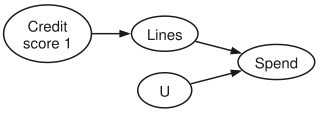

In [255]:
chh.draw_dag([("Credit\nscore 1", "Lines"), ("U", "Spend"), ("Lines", "Spend")])

### Noise-Inducing Controls

In [256]:
import pandas as pd, numpy as np, statsmodels.formula.api as smf
s = pd.read_csv("./data/spend_data_rnd.csv")

def row(label, f):
    m = smf.ols(f, data=s).fit()
    return dict(model=label, coef=m.params["np.sqrt(credit_limit)"],
                std_err=m.bse["np.sqrt(credit_limit)"])

# a noise-inducing control predicts T, not Y: same estimate, a bigger SE
pd.DataFrame([
    row("no control", "spend ~ np.sqrt(credit_limit)"),
    row("+ score bucket (noise-inducing)",
        "spend ~ np.sqrt(credit_limit) + C(credit_score1_buckets)"),
]).round(4)

,model,coef,std_err
0,no control,16.2915,2.9883
1,+ score bucket (noise-inducing),14.5953,3.5233


## Check Yourself: Predict the Bias Sign

Before looking at data, predict whether the short model is upward or downward biased.

### Example 1: Studying and Test Scores

DAG: Ability → Study time, Ability → Test score

You estimate: Test_score ~ Study_time (omitting ability)

<b style="color:#73000A;">Predict</b>: Bias up, down, or zero?

**Answer**: Biased **upward**.

Reasoning:
- High-ability students study more: correlation is positive
- High-ability students score higher: true effect is positive
- Both push the coefficient up

Bias = (+) × (+) = **positive**

The true effect of studying is lower than the naive estimate.

### Example 2: Years in Market and Earnings

DAG: Intelligence → Years_worked, Intelligence → Earnings

You estimate: Earnings ~ Years_worked (omitting intelligence)

<b style="color:#73000A;">Predict</b>: Bias up, down, or zero?

**Answer**: Biased **upward**.

Reasoning:
- Smarter people stay in market longer: correlation is positive
- Smarter people earn more: true effect is positive
- Both push up the coefficient

Bias = (+) × (+) = **positive**

Part of what looks like return to experience is actually return to intelligence.

### Example 3: Drug Use and Health Outcomes

DAG: Health_status → Drug_use, Health_status → Outcomes

You estimate: Outcomes ~ Drug_use (omitting health status)

<b style="color:#73000A;">Predict</b>: Bias up, down, or zero?

**Answer**: Biased **downward**.

Reasoning:
- Sick people use more drugs: correlation is positive
- Sick people have worse outcomes: true effect is negative
- These push in opposite directions

Bias = (+) × (-) = **negative**

The drug might actually help, but omitting health status makes it look worse.

### Example 4: Class Size and Test Scores

DAG: School_funding → Class_size, School_funding → Test_scores

You estimate: Test_scores ~ Class_size (omitting school funding)

<b style="color:#73000A;">Predict</b>: Bias up or down?

**Answer**: Biased **downward** (reversed!).

Reasoning:
- Well-funded schools have smaller classes: (Class_size, Funding) correlation is negative
- Well-funded schools have higher scores: true effect is positive
- These push in opposite directions

Bias = (-) × (+) = **negative**

The true effect of class size is actually larger than the naive estimate.

### Decomposition Practice

Given:
- Short model (omits confounder W): coefficient = 0.8
- W affects T with coefficient 0.5
- W affects Y with effect 1.2

Calculate the true long model coefficient.

<b style="color:#73000A;">Solution</b>: Bias = 0.5 × 1.2 = 0.6; True coefficient = 0.8 - 0.6 = 0.2

### Controls That Create Bias

Two of the three failure modes from last lecture are decisions about <b style="color:#73000A;">which controls to include</b>, so they belong in this list:

- A <b style="color:#73000A;">mediator</b> sits on the path from treatment to outcome. Control for it and you delete the part of the effect that travels through it. The cigar tax looked harmless once we controlled for cigarettes smoked
- A <b style="color:#73000A;">collider</b> is caused by the treatment and the outcome together. Control for it, or select your sample on it, and you open a path that was closed. Beauty and talent were unrelated until we looked only at movie stars

- Neither shows up in the regression output. A coefficient that moves when you add a control tells you nothing about which of these you just did
- The only thing that separates a confounder from a mediator or a collider is the graph you drew before running anything

### Feature Selection: Bias-Variance Trade-Off

- Confounders must be included (bias reduction)
- Neutral controls help if predictive of Y
- Noise-inducing controls hurt (variance increase)
- The hard part: distinguishing between them in observational data

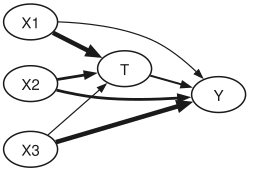

In [257]:
pos = {"X1": (0, 2.1), "X2": (0, 0), "X3": (0, -2.1), "T": (3.0, -1.1), "Y": (6.0, 1.1)}
chh.draw_dag([("X1", "T", 4.6), ("X2", "T", 2.8), ("X3", "T", 1.2),
              ("X1", "Y", 1.2), ("X2", "Y", 2.8), ("X3", "Y", 4.6), ("T", "Y", 2.0)],
             pos=pos)

### When a Confounder Costs More Than It Buys

Simulate the graph above: $X_1$ moves the treatment hard and the outcome barely, $X_3$ the other way round, $X_2$ in between. The true effect is <b style="color:#73000A;">0.05</b>.

- Control for all three and the estimate is unusable: the confidence interval swallows everything
- Because $X_1$ explains away most of the treatment's variation, and we just saw that variation is what the standard error lives on
- Drop $X_1$ and the estimate is biased, and far more useful
- Sometimes trading a little bias for a lot of precision is the right call, and sometimes it is not

In [258]:
np.random.seed(123)
n = 100

x1, x2, x3 = (np.random.normal(0, 1, n) for _ in range(3))
t = np.random.normal(10 * x1 + 5 * x2 + x3)     # x1 dominates the treatment
y = np.random.normal(0.05 * t + x1 + 5 * x2 + 10 * x3, 5)   # true effect 0.05
df = pd.DataFrame(dict(y=y, t=t, x1=x1, x2=x2, x3=x3))

all_three = smf.ols("y ~ t + x1 + x2 + x3", data=df).fit()
drop_x1 = smf.ols("y ~ t + x2 + x3", data=df).fit()

pd.DataFrame({
    "model": ["control for x1, x2, x3", "drop x1, keep x2, x3"],
    "effect (truth is 0.05)": [all_three.params["t"], drop_x1.params["t"]],
    "std err": [all_three.bse["t"], drop_x1.bse["t"]],
    "p-value": [all_three.pvalues["t"], drop_x1.pvalues["t"]],
}).round(4)

,model,effect (truth is 0.05),std err,p-value
0,"control for x1, x2, x3",0.8664,0.6070,0.1567
1,"drop x1, keep x2, x3",0.1585,0.0465,0.0010


### The Same Trade-Off, Two Places

| | Bias comes from | Variance comes from |
|---|---|---|
| <b style="color:#73000A;">Choosing controls</b> | omitting a confounder | adding a noise-inducing control |
| <b style="color:#73000A;">Choosing flexibility</b> | a model too rigid to fit the truth | a model flexible enough to fit noise |

- Causal work usually pays variance to buy <b style="color:#73000A;">less bias</b>
- Prediction work usually pays bias to buy <b style="color:#73000A;">less variance</b>

### Practical Example: Public or Private Schools?

- Do private schools raise income? Raw gap: private graduates earn more
- But parents' income, SAT, and ambition all push on <b style="color:#73000A;">both</b> doors
- Add the controls one at a time and the private premium <b style="color:#73000A;">shrinks toward zero</b>
- The DAG tells you which controls close the back doors

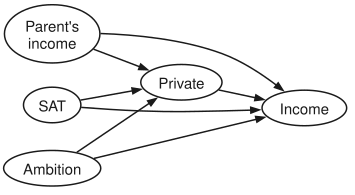

In [259]:
chh.draw_dag([("Parent's\nincome", "Private"), ("SAT", "Private"), ("Ambition", "Private"),
              ("Parent's\nincome", "Income"), ("SAT", "Income"), ("Ambition", "Income"),
              ("Private", "Income")])

## Key Ideas

- <b style="color:#73000A;">Why regression at all:</b> the adjustment formula runs out of data long before you run out of controls
- <b style="color:#73000A;">What it solves:</b> the best linear prediction problem, $\hat{\beta} = (X'X)^{-1}X'y$. Causality comes from what is in $X$, never from the algebra
- <b style="color:#73000A;">Frisch-Waugh-Lovell:</b> debias the treatment, denoise the outcome, then run one small regression. Geometrically, drop a perpendicular
- <b style="color:#73000A;">Orthogonalization:</b> a treatment you cannot predict from $X$ is as good as randomly assigned, given $X$
- <b style="color:#73000A;">Two lenses:</b> clean the treatment or impute the outcome. Getting either one right is enough
- <b style="color:#73000A;">Dummies and fixed effects:</b> one intercept per group, or subtract the group mean. Same number, three ways
- <b style="color:#73000A;">What regression averages:</b> group effects weighted by treatment variance, not sample size
- <b style="color:#73000A;">Choosing controls:</b> confounders remove bias, outcome predictors buy precision, treatment predictors cost it. The graph decides, the output cannot